In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import json

In [2]:
data_dir = '../data/metrics'

## Read Data

In [3]:
v2_results = json.load(open(f'{data_dir}/v2_batch_integration.json'))

In [4]:
v2_df = pd.json_normalize(v2_results).replace('NA', np.nan)

/var/folders/zb/wdq2xwvj55q9jphdjvr9131jxgjpwb/T/ipykernel_75471/1449546011.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  v2_df = pd.json_normalize(v2_results).replace('NA', np.nan)


In [5]:
v2_df.columns

Index(['dataset_id', 'method_id', 'mean_score', 'normalization_id', 'task_id',
       'metric_values.ari', 'metric_values.asw_batch',
       'metric_values.asw_label', 'metric_values.graph_connectivity',
       'metric_values.hvg_overlap', 'metric_values.isolated_label_asw',
       'metric_values.isolated_label_f1', 'metric_values.kbet',
       'metric_values.nmi', 'metric_values.pcr', 'scaled_scores.ari',
       'scaled_scores.asw_batch', 'scaled_scores.asw_label',
       'scaled_scores.graph_connectivity', 'scaled_scores.hvg_overlap',
       'scaled_scores.isolated_label_asw', 'scaled_scores.isolated_label_f1',
       'scaled_scores.kbet', 'scaled_scores.nmi', 'scaled_scores.pcr',
       'resources.exit_code', 'resources.duration_sec', 'resources.cpu_pct',
       'resources.peak_memory_mb', 'resources.disk_read_mb',
       'resources.disk_write_mb'],
      dtype='object')

In [6]:
v1_results = []
for output_type in ['feature', 'embed', 'graph']:
    with open(f'{data_dir}/v1_batch_integration_{output_type}.json') as f:
        v1_results.extend(json.load(f))

In [7]:
v1_df = pd.json_normalize(v1_results)

In [8]:
v1_df.columns

Index(['task_id', 'commit_sha', 'method_id', 'dataset_id', 'submission_time',
       'code_version', 'mean_score', 'resources.duration_sec',
       'resources.cpu_pct', 'resources.peak_memory_mb',
       'resources.disk_read_mb', 'resources.disk_write_mb',
       'metric_values.ari', 'metric_values.cc_score',
       'metric_values.graph_connectivity', 'metric_values.hvg_conservation',
       'metric_values.isolated_labels_f1', 'metric_values.isolated_labels_sil',
       'metric_values.kBET', 'metric_values.nmi', 'metric_values.pcr',
       'metric_values.silhouette', 'metric_values.silhouette_batch',
       'scaled_scores.ari', 'scaled_scores.cc_score',
       'scaled_scores.graph_connectivity', 'scaled_scores.hvg_conservation',
       'scaled_scores.isolated_labels_f1', 'scaled_scores.isolated_labels_sil',
       'scaled_scores.kBET', 'scaled_scores.nmi', 'scaled_scores.pcr',
       'scaled_scores.silhouette', 'scaled_scores.silhouette_batch'],
      dtype='object')

## Get comparison table

In [9]:
metric_prefix = 'metric_values.'
metric_map = {x.replace(metric_prefix, ''): x.replace(metric_prefix, '') for x in v1_df.columns if x.startswith(metric_prefix)}
metric_map |= {
    'cc_conservation': 'cc_score',
    'hvg_overlap': 'hvg_conservation',
    'isolated_label_f1': 'isolated_labels_f1',
    'isolated_label_asw': 'isolated_labels_sil',
    'asw_label': 'silhouette',
    'asw_batch': 'silhouette_batch',
}

In [10]:
[x for x in v1_df.columns if x not in v2_df.columns and x.startswith(metric_prefix)]

['metric_values.cc_score',
 'metric_values.hvg_conservation',
 'metric_values.isolated_labels_f1',
 'metric_values.isolated_labels_sil',
 'metric_values.kBET',
 'metric_values.silhouette',
 'metric_values.silhouette_batch']

In [11]:
[x for x in v2_df.columns if x not in v1_df.columns and x.startswith(metric_prefix)]

['metric_values.asw_batch',
 'metric_values.asw_label',
 'metric_values.hvg_overlap',
 'metric_values.isolated_label_asw',
 'metric_values.isolated_label_f1',
 'metric_values.kbet']

Map v2 metrics to v1 names

In [12]:
v2_df = v2_df.rename(metric_map)

### Merge the two tables

In [13]:
v1_df['version'] = 'v1'
v2_df['version'] = 'v2'
merge_columns = ['method_id', 'dataset_id']

In [14]:
# rename v1 datasets
v1_df['dataset_id'] = v1_df['dataset_id'].apply(lambda x: f"openproblems_v1/{x.replace('_batch', '')}")

In [15]:
# subset to unscaled HVG methods
v1_df = v1_df[v1_df['method_id'].str.endswith('_hvg_unscaled')]

In [16]:
# subset to v1 datasets
v2_df = v2_df[v2_df['dataset_id'].str.startswith('openproblems_v1/')]

In [17]:
# harmonise method naming
method_map = {x: x for x in v2_df['method_id'].unique()}
method_map |= {
    'bbknn_hvg_unscaled': 'bbknn',
    'combat_hvg_unscaled': 'combat',
    'fastmnn_embed_hvg_unscaled': 'fastmnn_embedding',
    'fastmnn_feature_hvg_unscaled': 'fastmnn_feature',
    # 'harmony_hvg_unscaled': 'harmony',
    'liger_hvg_unscaled': 'liger',
    'mnn_hvg_unscaled': 'mnn_correct',
    'scanorama_embed_hvg_unscaled': 'scanorama_embed',
    'scanorama_feature_hvg_unscaled': 'scanorama_feature',
    'scanvi_hvg_unscaled': 'scanvi',
    'scvi_hvg_unscaled': 'scvi',
}

In [18]:
v1_df['method_id_v1'] = v1_df['method_id'].copy()
v1_df['method_id'] = v1_df['method_id'].map(method_map)

In [19]:
v1_df_melted = v1_df.melt(
    id_vars=[x for x in v1_df.columns if not x.startswith('metric_values.')],
    var_name='metric',
    value_name='value'
)
v1_df_melted['metric'] = v1_df_melted['metric'].str.replace('metric_values.', '')

# v1_df_melted = v1_df_melted.melt(
#     id_vars=[x for x in v1_df_melted.columns if not x.startswith('scaled_scores.')],
#     var_name='scaled_metric',
#     value_name='scaled_value'
# )
# v1_df_melted['scaled_metric'] = v1_df_melted['scaled_metric'].str.replace('scaled_scores.', '')

v1_df_melted.head()

,task_id,commit_sha,method_id,dataset_id,submission_time,code_version,mean_score,resources.duration_sec,resources.cpu_pct,resources.peak_memory_mb,...,scaled_scores.isolated_labels_sil,scaled_scores.kBET,scaled_scores.nmi,scaled_scores.pcr,scaled_scores.silhouette,scaled_scores.silhouette_batch,version,method_id_v1,metric,value
0,batch_integration_feature,65efdc87e3f4048b94b98c6f9fbfe10dae8d5ab0,combat,openproblems_v1/pancreas,2023-02-21 18:03:02.335,1.9.2,0.644252,994.0,205.0,3200.0,...,0.353524,0.118287,0.908611,0.999956,0.300567,0.615307,v1,combat_hvg_unscaled,ari,0.944240
1,batch_integration_feature,65efdc87e3f4048b94b98c6f9fbfe10dae8d5ab0,fastmnn_feature,openproblems_v1/pancreas,2023-02-21 18:03:02.440,1.14.1,0.503828,1099.0,149.8,5200.0,...,0.284206,0.374808,0.841293,0.700167,0.556019,0.175285,v1,fastmnn_feature_hvg_unscaled,ari,0.841111
2,batch_integration_feature,65efdc87e3f4048b94b98c6f9fbfe10dae8d5ab0,scanorama_feature,openproblems_v1/pancreas,2023-02-21 18:03:02.120,1.7,0.419133,1229.0,352.5,4700.0,...,0.461569,0.198947,0.829861,0.529342,0.371818,0.386174,v1,scanorama_feature_hvg_unscaled,ari,0.656787
3,batch_integration_feature,65efdc87e3f4048b94b98c6f9fbfe10dae8d5ab0,mnn_correct,openproblems_v1/pancreas,2023-02-21 18:03:02.547,0.1.9.5,0.575577,1459.0,442.0,73600.0,...,0.410475,0.138410,0.839186,0.670481,0.326270,0.644014,v1,mnn_hvg_unscaled,ari,0.806673
4,batch_integration_feature,65efdc87e3f4048b94b98c6f9fbfe10dae8d5ab0,combat,openproblems_v1/lung,2023-02-21 18:02:02.612,1.9.2,0.535825,853.0,131.9,5000.0,...,0.269802,0.051885,0.713953,0.999955,0.251961,0.567740,v1,combat_hvg_unscaled,ari,0.550294


In [20]:
v2_df_melted = v2_df.melt(
    id_vars=[x for x in v2_df.columns if not x.startswith('metric_values.')],
    var_name='metric',
    value_name='value'
)
v2_df_melted['metric'] = v2_df_melted['metric'].str.replace('metric_values.', '')

# v2_df_melted = v2_df_melted.melt(
#     id_vars=[x for x in v2_df_melted.columns if not x.startswith('scaled_scores.')],
#     var_name='scaled_metric',
#     value_name='scaled_value'
# )
# v2_df_melted['scaled_metric'] = v2_df_melted['scaled_metric'].str.replace('scaled_scores.', '')

v2_df_melted.head()

,dataset_id,method_id,mean_score,normalization_id,task_id,scaled_scores.ari,scaled_scores.asw_batch,scaled_scores.asw_label,scaled_scores.graph_connectivity,scaled_scores.hvg_overlap,...,scaled_scores.pcr,resources.exit_code,resources.duration_sec,resources.cpu_pct,resources.peak_memory_mb,resources.disk_read_mb,resources.disk_write_mb,version,metric,value
0,openproblems_v1/cengen,bbknn,0.0976,log_cp10k,batch_integration,0.0000,0.0000,0.0000,0.9763,0.0,...,0.0000,0,308.0,324.6,12391.0,302.0,899.0,v2,ari,NaN
1,openproblems_v1/cengen,combat,0.0000,log_cp10k,batch_integration,0.0000,0.0000,0.0000,0.0000,0.0,...,0.0000,137,749.0,NaN,NaN,NaN,NaN,v2,ari,NaN
2,openproblems_v1/cengen,fastmnn_embedding,0.4471,log_cp10k,batch_integration,0.5256,0.6254,0.3394,0.8382,0.0,...,0.0534,0,505.0,99.6,10957.0,315.0,304.0,v2,ari,0.5256
3,openproblems_v1/cengen,fastmnn_feature,0.0000,log_cp10k,batch_integration,0.0000,0.0000,0.0000,0.0000,0.0,...,0.0000,1,1461.0,NaN,NaN,NaN,NaN,v2,ari,NaN
4,openproblems_v1/cengen,liger,0.0000,log_cp10k,batch_integration,0.0000,0.0000,0.0000,0.0000,0.0,...,0.0000,143,14953.0,NaN,NaN,NaN,NaN,v2,ari,NaN


In [21]:
merged_metrics = v1_df_melted.merge(v2_df_melted, on=merge_columns + ['metric'], suffixes=('_v1', '_v2'))
merged_metrics.head()

,task_id_v1,commit_sha,method_id,dataset_id,submission_time,code_version,mean_score_v1,resources.duration_sec_v1,resources.cpu_pct_v1,resources.peak_memory_mb_v1,...,scaled_scores.nmi_v2,scaled_scores.pcr_v2,resources.exit_code,resources.duration_sec_v2,resources.cpu_pct_v2,resources.peak_memory_mb_v2,resources.disk_read_mb_v2,resources.disk_write_mb_v2,version_v2,value_v2
0,batch_integration_feature,65efdc87e3f4048b94b98c6f9fbfe10dae8d5ab0,combat,openproblems_v1/pancreas,2023-02-21 18:03:02.335,1.9.2,0.644252,994.0,205.0,3200.0,...,0.7902,1.0000,0,344.0,117.2,15770.0,340.0,2970.0,v2,0.7242
1,batch_integration_feature,65efdc87e3f4048b94b98c6f9fbfe10dae8d5ab0,fastmnn_feature,openproblems_v1/pancreas,2023-02-21 18:03:02.440,1.14.1,0.503828,1099.0,149.8,5200.0,...,0.8676,0.4552,0,717.0,80.9,24167.0,361.0,2970.0,v2,0.8592
2,batch_integration_feature,65efdc87e3f4048b94b98c6f9fbfe10dae8d5ab0,scanorama_feature,openproblems_v1/pancreas,2023-02-21 18:03:02.120,1.7,0.419133,1229.0,352.5,4700.0,...,0.1173,0.0000,0,854.0,819.0,24269.0,344.0,1741.0,v2,0.0375
3,batch_integration_feature,65efdc87e3f4048b94b98c6f9fbfe10dae8d5ab0,mnn_correct,openproblems_v1/pancreas,2023-02-21 18:03:02.547,0.1.9.5,0.575577,1459.0,442.0,73600.0,...,0.0000,0.0000,143,14402.0,NaN,NaN,NaN,NaN,v2,NaN
4,batch_integration_embed,65efdc87e3f4048b94b98c6f9fbfe10dae8d5ab0,scanorama_feature,openproblems_v1/pancreas,2023-02-21 18:03:03.612,1.7,0.540733,549.0,691.1,3700.0,...,0.1173,0.0000,0,854.0,819.0,24269.0,344.0,1741.0,v2,0.0375


# Plot results

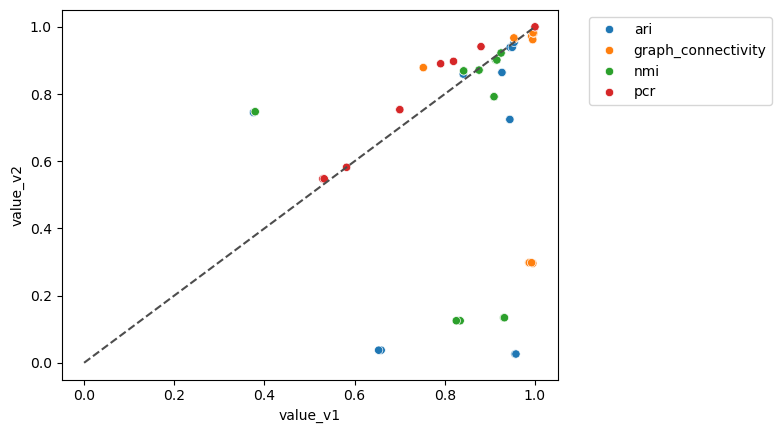

In [22]:
sns.scatterplot(
    data=merged_metrics,
    x='value_v1',
    y='value_v2',
    hue='metric'
)

plt.plot((0,1), (0,1), ls="--", c=".3")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

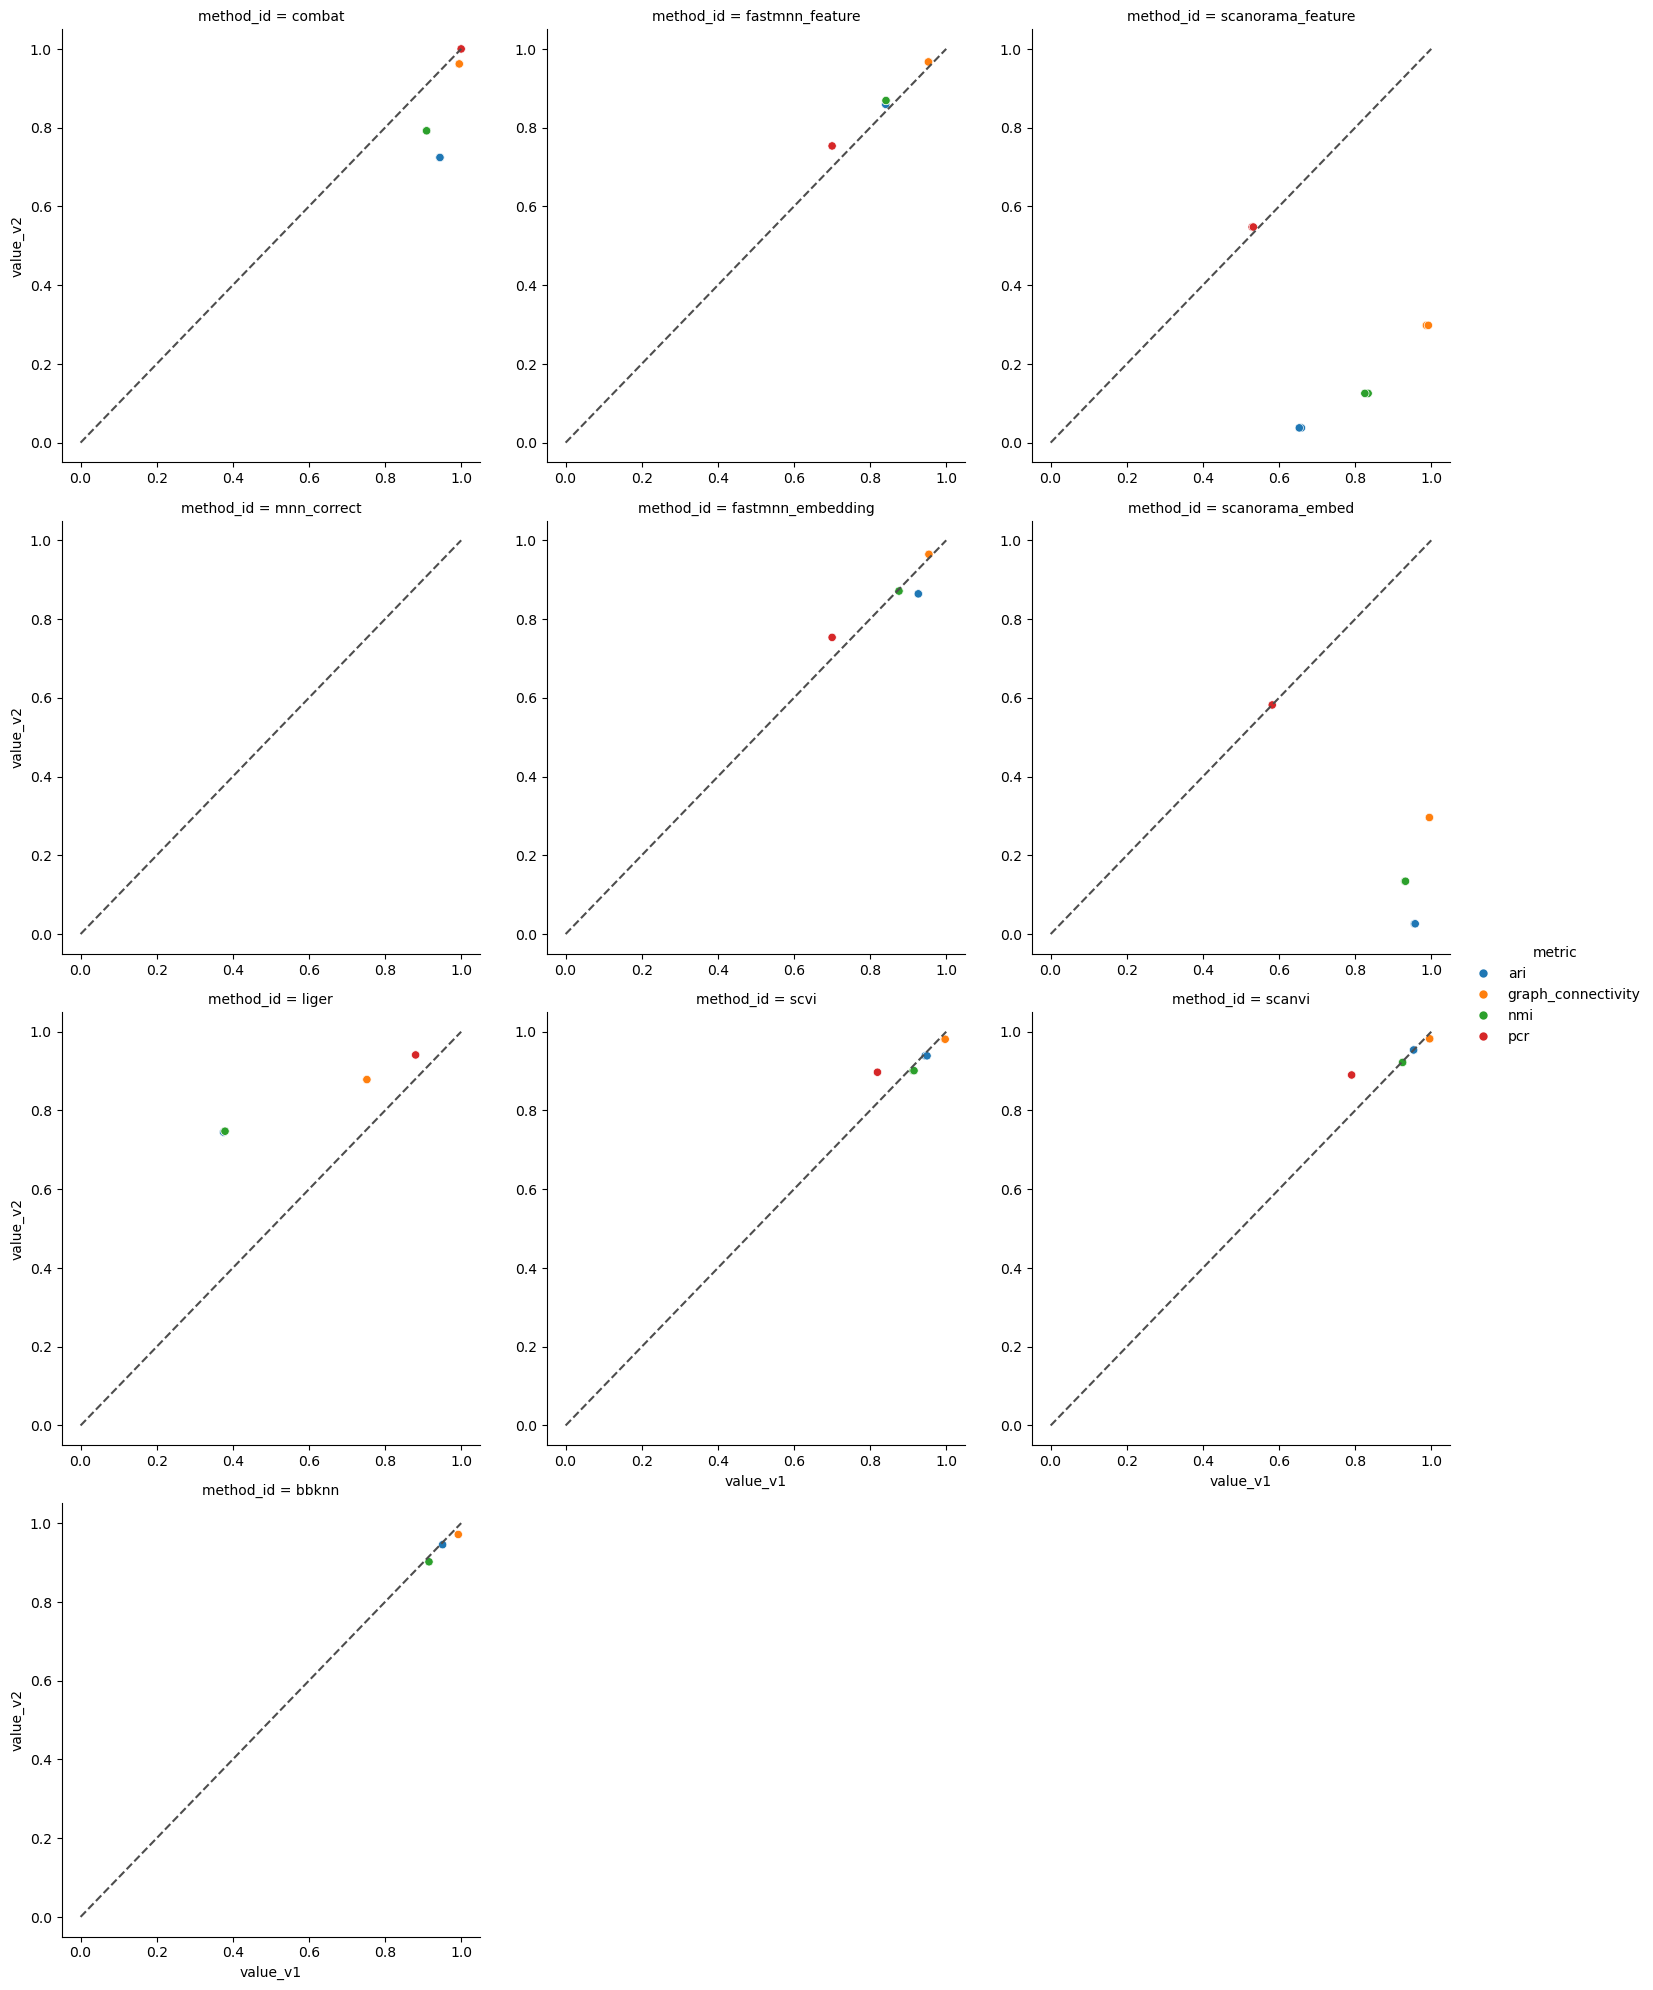

In [23]:
sns.relplot(
    data=merged_metrics,
    x='value_v1',
    y='value_v2',
    kind='scatter',
    hue='metric',
    col='method_id',
    col_wrap=3,
    facet_kws={'sharex': False, 'sharey': False},
)
for ax in plt.gcf().get_axes():
    ax.plot((0,1), (0,1), ls="--", c=".3")

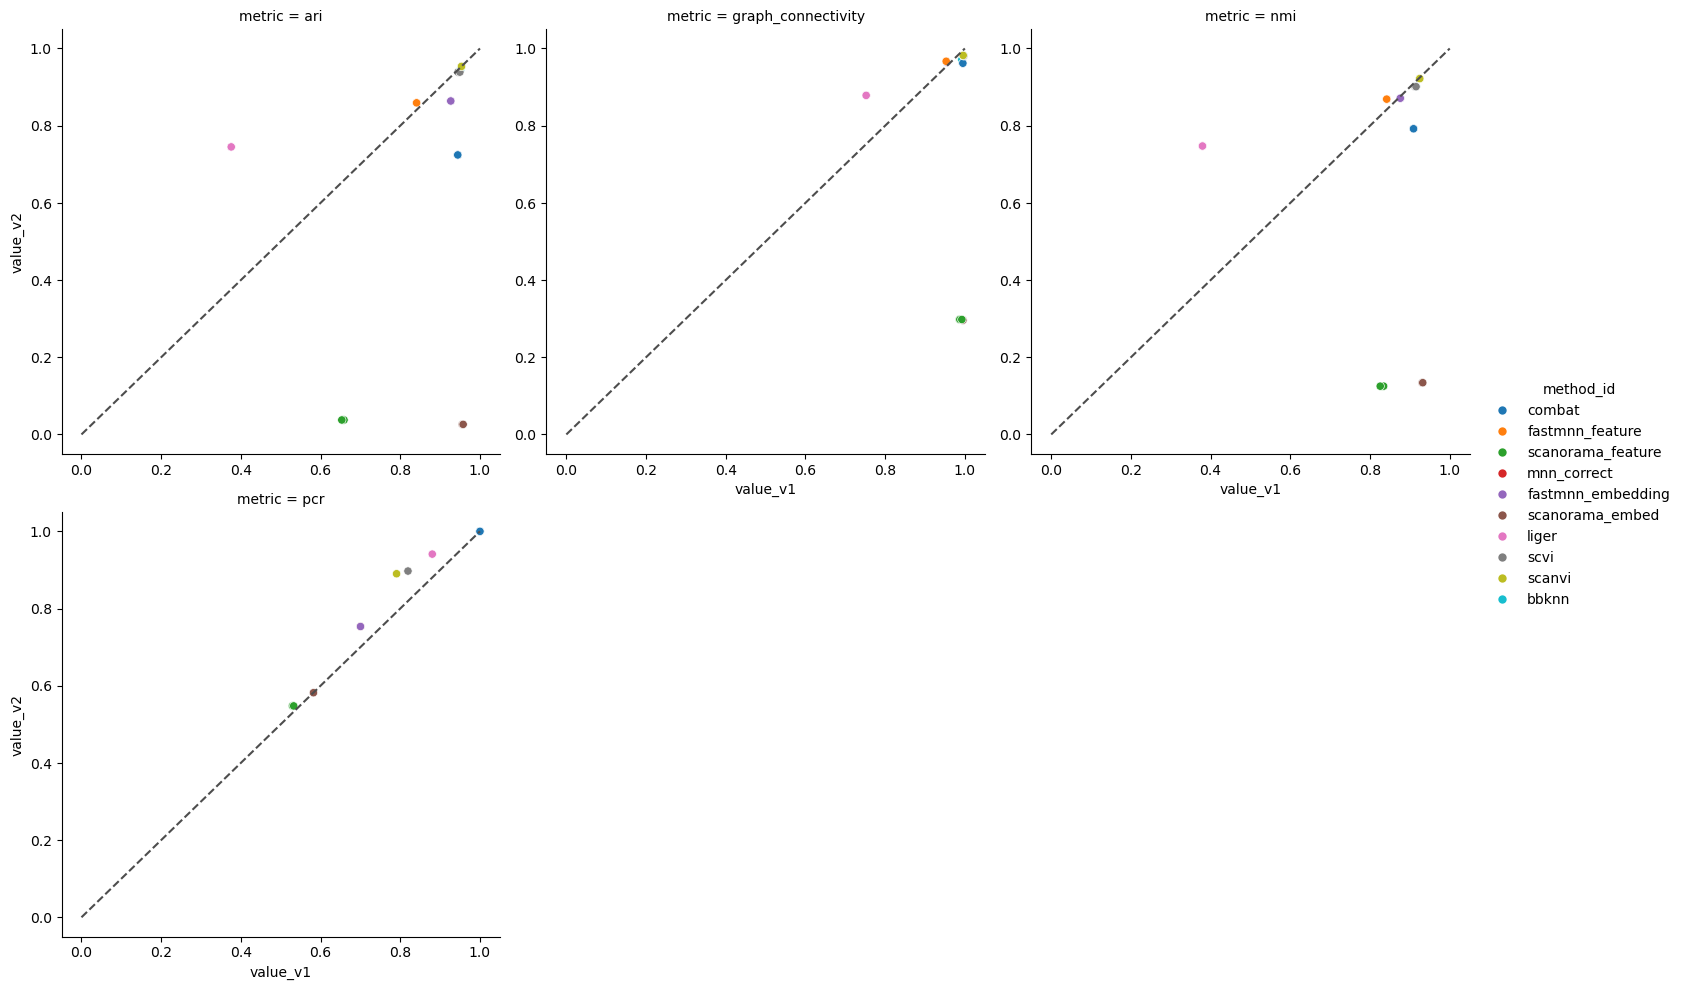

In [24]:
sns.relplot(
    data=merged_metrics,
    x='value_v1',
    y='value_v2',
    kind='scatter',
    hue='method_id',
    col='metric',
    col_wrap=3,
    facet_kws={'sharex': False, 'sharey': False},
)
for ax in plt.gcf().get_axes():
    ax.plot((0,1), (0,1), ls="--", c=".3")